<a href="https://colab.research.google.com/github/vijithq/nlp-project/blob/main/nlp_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import files
uploaded = files.upload()

Saving fashion_dataset_500.csv to fashion_dataset_500 (1).csv


In [21]:
import pandas as pd

df = pd.read_csv('fashion_dataset_500.csv')
df.head()

,Date,Text,Trend,Location
0,2023-08-27,Preppy fashion feels classy and elegant #y2k,Y2K,London
1,2022-09-26,Y2K style is amazing and trendy #vintage,Vintage,Tokyo
2,2023-01-09,This goth look is terrible and too dark #minim...,Minimalist,New York
3,2021-11-02,Streetwear is too expensive and bad quality #goth,Goth,Milan
4,2022-10-04,Vintage clothes sometimes smell bad #bohemian,Bohemian,Milan


In [22]:
print(df.columns)
print(df.isnull().sum())
print(df.shape)

Index(['Date', 'Text', 'Trend', 'Location'], dtype='object')
Date        0
Text        0
Trend       0
Location    0
dtype: int64
(500, 4)


In [23]:
df['Text'] = df['Text'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Text', 'Date'])

In [24]:
!pip install nltk

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [25]:
class SentimentAnalyzer:
    def __init__(self):
        self.sia = SentimentIntensityAnalyzer()

    def analyze(self, text):
        score = self.sia.polarity_scores(text)['compound']

        if score >= 0.05:
            return "Positive", score
        elif score <= -0.05:
            return "Negative", score
        else:
            return "Neutral", score

analyzer = SentimentAnalyzer()

# Apply to dataset
df[['Sentiment_Label', 'Sentiment_Score']] = df['Text'].apply(
    lambda x: pd.Series(analyzer.analyze(x))
)

df.head(20)   # first 20 rows


,Date,Text,Trend,Location,Sentiment_Label,Sentiment_Score
0,2023-08-27,Preppy fashion feels classy and elegant #y2k,Y2K,London,Positive,0.7184
1,2022-09-26,Y2K style is amazing and trendy #vintage,Vintage,Tokyo,Positive,0.5859
2,2023-01-09,This goth look is terrible and too dark #minim...,Minimalist,New York,Negative,-0.4767
3,2021-11-02,Streetwear is too expensive and bad quality #goth,Goth,Milan,Negative,-0.5423
4,2022-10-04,Vintage clothes sometimes smell bad #bohemian,Bohemian,Milan,Negative,-0.5423
5,2023-08-16,Y2K style is amazing and trendy #preppy,Preppy,Los Angeles,Positive,0.5859
6,2021-06-25,Y2K style is amazing and trendy #y2k,Y2K,Los Angeles,Positive,0.5859
7,2022-01-10,Streetwear is too expensive and bad quality #b...,Bohemian,Los Angeles,Negative,-0.5423
8,2022-03-25,Bohemian dresses are perfect for summer #minim...,Minimalist,Tokyo,Positive,0.5719
9,2022-10-07,Y2K trend is too flashy and weird #streetwear,Streetwear,Paris,Negative,-0.1779


In [26]:
df['Month'] = df['Date'].dt.to_period('M')
df['Year'] = df['Date'].dt.year

monthly_trends = df.groupby(['Month', 'Trend']).size().reset_index(name='Count')
yearly_trends = df.groupby(['Year', 'Trend']).size().reset_index(name='Count')

monthly_trends.head(20)

,Month,Trend,Count
0,2021-01,Bohemian,2
1,2021-01,Goth,1
2,2021-01,Minimalist,2
3,2021-01,Preppy,3
4,2021-01,Streetwear,6
5,2021-01,Y2K,3
6,2021-02,Bohemian,1
7,2021-02,Goth,3
8,2021-02,Minimalist,3
9,2021-02,Preppy,2


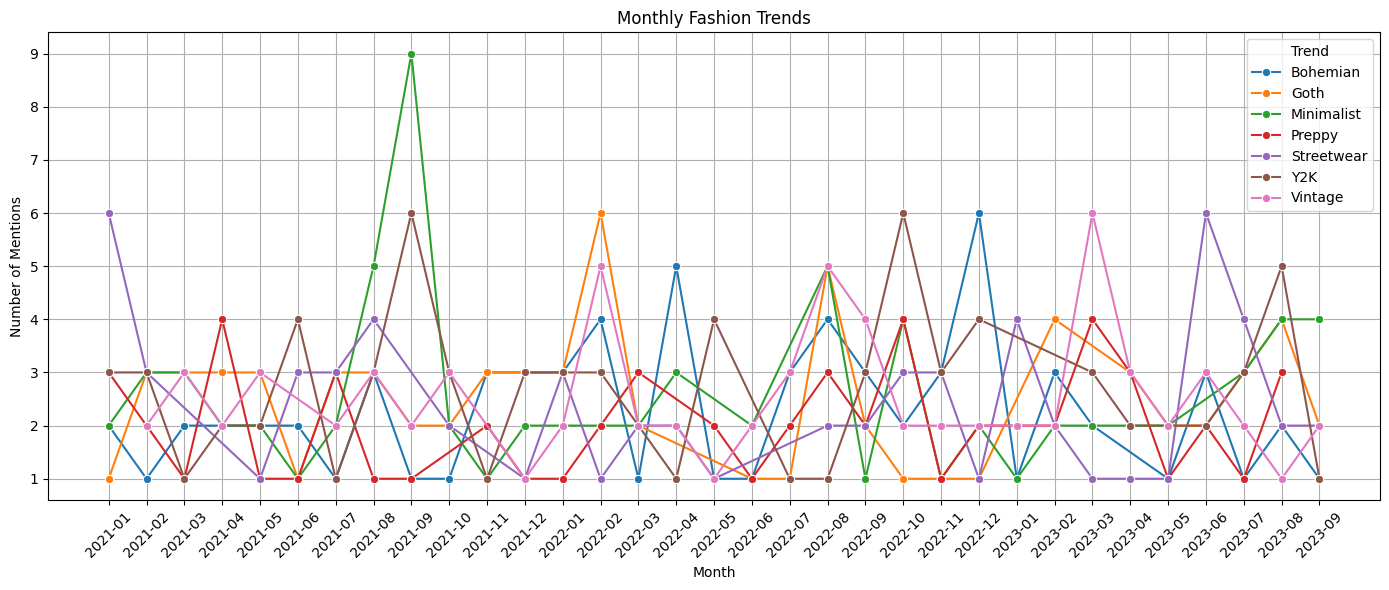

In [33]:
%matplotlib inline
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_trends.sort_values('Month'),
    x='Month',
    y='Count',
    hue='Trend',
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Monthly Fashion Trends")
plt.xlabel("Month")
plt.ylabel("Number of Mentions")

plt.grid(True)
plt.tight_layout()

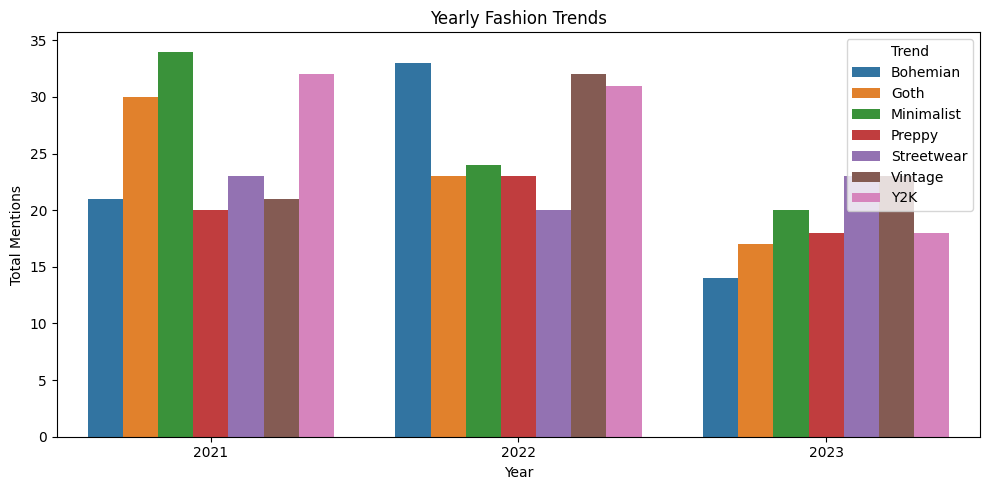

In [34]:
%matplotlib inline
plt.figure(figsize=(10,5))

sns.barplot(
    data=yearly_trends,
    x='Year',
    y='Count',
    hue='Trend'
)

plt.title("Yearly Fashion Trends")
plt.xlabel("Year")
plt.ylabel("Total Mentions")

plt.tight_layout()


In [41]:
from nltk.sentiment import SentimentIntensityAnalyzer

class SentimentAnalyzer:
    def __init__(self):
        self.sia = SentimentIntensityAnalyzer()

    def analyze(self, text):
        score = self.sia.polarity_scores(text)['compound']
        if score >= 0.05:
            return "Positive", score
        elif score <= -0.05:
            return "Negative", score
        else:
            return "Neutral", score

analyzer = SentimentAnalyzer()

results = df['Text'].apply(lambda x: analyzer.analyze(x))

df['Sentiment_Label'] = results.apply(lambda x: x[0])
df['Sentiment_Score'] = results.apply(lambda x: x[1])

In [42]:
print(df.columns)

Index(['Date', 'Text', 'Trend', 'Location', 'Month', 'Sentiment_Label',
       'Sentiment_Score'],
      dtype='object')


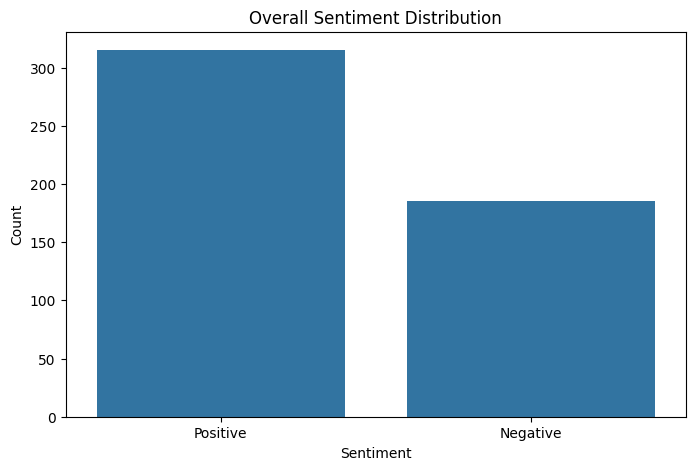

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Sentiment_Label')

plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [44]:
class AdvancedAnalytics:
    def __init__(self, df):
        self.df = df
        self.df['clean_text'] = df['Text'].str.lower()

    def detect_issues(self):
        print("\n--- Issue Detection ---")
        issues = {
            "delivery": ["delivery", "shipping"],
            "quality": ["quality", "fabric", "material"],
            "size": ["size", "fit"],
            "price": ["price", "expensive", "cost"]
        }

        for issue, words in issues.items():
            count = self.df['clean_text'].str.contains('|'.join(words)).sum()
            print(f"{issue}: {count}")

    def detect_themes(self):
        print("\n--- Theme Detection ---")
        themes = {
            "casual": ["casual", "daily"],
            "party": ["party", "night"],
            "summer": ["summer", "hot"]
        }

        for theme, words in themes.items():
            count = self.df['clean_text'].str.contains('|'.join(words)).sum()
            print(f"{theme}: {count}")

    def top_trend(self):
        print("\n--- Top Trend ---")
        print(self.df['Trend'].value_counts().head())

analytics = AdvancedAnalytics(df)

analytics.detect_issues()
analytics.detect_themes()
analytics.top_trend()


--- Issue Detection ---
delivery: 0
quality: 67
size: 63
price: 69

--- Theme Detection ---
casual: 0
party: 0
summer: 35

--- Top Trend ---
Trend
Y2K           81
Minimalist    78
Vintage       76
Goth          70
Bohemian      68
Name: count, dtype: int64


In [45]:
location_trends = pd.crosstab(df['Trend'], df['Location'])

print("\nLocation-wise Trend Distribution:\n")
print(location_trends)


Location-wise Trend Distribution:

Location    London  Los Angeles  Milan  New York  Paris  Tokyo
Trend                                                         
Bohemian        17           13     14         9      7      8
Goth            11           14     14        12     10      9
Minimalist      16           20     11        11      5     15
Preppy          11           10      9        13     11      7
Streetwear       8            9     11        11     12     15
Vintage         15           18     10        10     13     10
Y2K             14           15      9         8     12     23


In [46]:
print("\n--- FINAL INSIGHTS ---")

# Most popular trend
print("Top Trend:", df['Trend'].value_counts().idxmax())

# Most positive trend
positive_trends = df[df['Sentiment_Label'] == 'Positive']['Trend'].value_counts()
print("Most Loved Trend:", positive_trends.idxmax())

# Most negative trend
negative_trends = df[df['Sentiment_Label'] == 'Negative']['Trend'].value_counts()
print("Most Criticized Trend:", negative_trends.idxmax())


--- FINAL INSIGHTS ---
Top Trend: Y2K
Most Loved Trend: Vintage
Most Criticized Trend: Y2K


In [ ]:
#future trend prediction

In [48]:
# Convert Month to datetime
monthly_trends['Month'] = pd.to_datetime(monthly_trends['Month'])

# Aggregate total counts per month (overall trend strength)
monthly_total = monthly_trends.groupby('Month')['Count'].sum().reset_index()

monthly_total = monthly_total.sort_values('Month')
monthly_total.set_index('Month', inplace=True)

monthly_total.head()

,Count
Month,
2021-01-01,17
2021-02-01,17
2021-03-01,13
2021-04-01,15
2021-05-01,12


In [49]:
import pandas as pd

# Moving average (window = 3 months)
monthly_total['Moving_Avg'] = monthly_total['Count'].rolling(window=3).mean()

# Forecast next 5 months
future_months = 5
last_date = monthly_total.index[-1]

future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='M')

forecast_values = []

last_values = list(monthly_total['Count'][-3:])  # last 3 months

for i in range(future_months):
    next_value = sum(last_values) / len(last_values)  # average
    forecast_values.append(next_value)

    last_values.pop(0)
    last_values.append(next_value)

forecast_df = pd.DataFrame({
    'Month': future_dates,
    'Forecast': forecast_values
})

forecast_df.set_index('Month', inplace=True)

forecast_df

/tmp/ipykernel_3053/4188540471.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_months, freq='M')


,Forecast
Month,
2023-10-31,15.666667
2023-11-30,16.222222
2023-12-31,14.629630
2024-01-31,15.506173
2024-02-29,15.452675


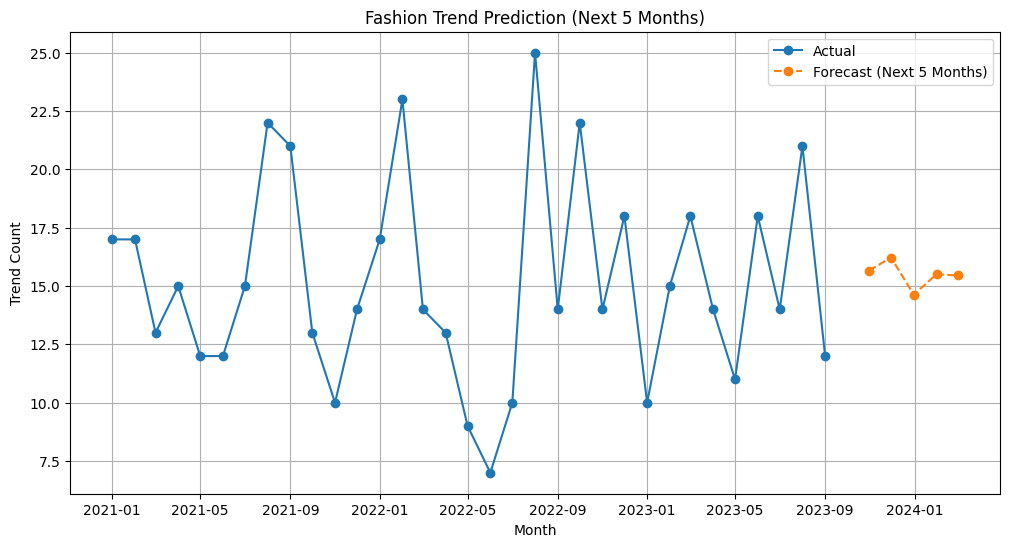

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Original data
plt.plot(monthly_total.index, monthly_total['Count'], label='Actual', marker='o')

# Forecast
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast (Next 5 Months)', marker='o', linestyle='--')

plt.title("Fashion Trend Prediction (Next 5 Months)")
plt.xlabel("Month")
plt.ylabel("Trend Count")

plt.legend()
plt.grid(True)

plt.show()

In [51]:
# Find most popular trend historically
top_trend = df['Trend'].value_counts().idxmax()

print("🔥 Predicted Dominating Trend in Future:", top_trend)

🔥 Predicted Dominating Trend in Future: Y2K
